In [1]:
# Imports
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
from jax import value_and_grad, vmap

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl

# Tracking with Non-Gaussian Observations

We here provide a tracking example with non-Gaussian observations, where observations consist of a bearing estimate (that lives in the circle, $S^1$) and a power estimate (that lives in $\mathbb{R}$).

Let the continuous-time latent state be planar position and velocity
$$
X_t =
\begin{bmatrix}
p_t \\ v_t
\end{bmatrix}
\in \mathbb{R}^4,
\qquad
p_t = (x_t,y_t),\; v_t = (\dot x_t,\dot y_t).
$$

## State dynamics (continuous-time SDE)

\begin{aligned}
dp_t &= v_t\,dt, \\
dv_t &= -\alpha\, v_t\,dt + \Sigma\, dW_t,
\end{aligned}
where $\alpha>0$ is a damping parameter, $\Sigma\in\mathbb{R}^{2\times 2}$ is a diffusion matrix, and $W_t$ is a 2D Brownian motion.

## Observation model (discrete-time, non-Gaussian)
At observation times $t_k = k\Delta$, a fixed sensor at location
$s=(s_x,s_y)\in\mathbb{R}^2$ measures the bearing angle *and* a noisy signal power, which are modeled as
$$
(Y_k, Z_k)\mid X_{t_k}\;\;\text{with}\;\;
\begin{cases}
Y_k \mid X_{t_k} \sim \mathrm{vonMises}\!\left(\mu_k,\;\kappa_y\right),\\[4pt]
Z_k \mid X_{t_k} \sim \mathcal{N}\!\left(m_k,\;\sigma_z^2\right),
\end{cases}
$$
typically taken conditionally independent given $X_{t_k}$:

- The bearing mean direction is
    $$
    \mu_k = \operatorname{atan2}\!\big(y_{t_k}-s_y,\; x_{t_k}-s_x\big),
    $$
    with concentration parameter $\kappa_y>0$.

- For signal power, let the range be
    $$
    r_k = \big\|p_{t_k}-s\big\|_2,
    $$
    and use a simple log-distance path-loss model (in dB/dBm):
    $$
    m_k = P_0 - 10\,n\,\log_{10}\!\left(\frac{r_k}{r_0}\right),
    $$
    where $P_0$ is the mean received power at reference distance $r_0$, $n>0$ is the path-loss exponent, and $\sigma_z^2$ is the (measurement) variance.

## Model specification: CDNLSSM with non-Gaussian observations.

We now showcase the implementation of the CDNLSSM model described above, according to the convention in cd-dynamax.

### The CD-NLSSM model definition

In [2]:
# Type annotations used for cd-dynamax dynamics and emission definitions
from typing import NamedTuple, Union
from jaxtyping import Array, Float

# Imports from dynamax
from cd_dynamax.dynamax.parameters import ParameterProperties, ParameterSet

# Usueful utilities for defining the CD-NLSSM dynamics and emission models
from cd_dynamax.src.continuous_discrete_nonlinear_gaussian_ssm.cdnlgssm_utils import (
    _get_params,
    LearnableVector,
    LearnableMatrix,
)

In [3]:
# CD-NLSSM model definition: 4-dimensional state x_t and 2-dimensional observations
state_dim=4
emission_dim=2

In [4]:
# Initial state distribution: Gaussian
from cd_dynamax.src.continuous_discrete_nonlinear_ssm.cdnlssm_utils import StaticGaussianDistribution
initial_mean=jnp.array([0.0, 0.0, 1.0, 0.5])
initial_cov=jnp.diag(
    jnp.array([0.5, 0.5, 0.2, 0.2]) ** 2
)

# Define the initial distribution as a StaticGaussianDistribution with the specified mean and covariance
initial_distribution = {
    "params": StaticGaussianDistribution(
        mean=initial_mean,
        cov=initial_cov
    ),
    "props": None,
}

In [5]:
# Dynamics: 
# Learnable drift function for bearing tracking model
class Learnable_BearingDrift(NamedTuple):
    # Learnable parameters
    alpha: Union[Float[Array, "1"], ParameterProperties]

    # Drift function: simple velocity model with learnable damping (bearing drift)
    def f(self, x, u=None, t=None):
        px, py, vx, vy = x
        return jnp.array([vx, vy, -self.alpha * vx, -self.alpha * vy])

    # Utility function to extract the learnable parameters as a dictionary
    def get_params(self):
        return _get_params(self.alpha)


**The Bearing Emission Model**

We first define a class with the Bearing Emission model
    - See basic definition and other examples in [cd_dynamax/src/continuous_discrete_nonlinear_ssm/cdnlssm_utils.py](../../../cd_dynamax/src/continuous_discrete_nonlinear_ssm/cdnlssm_utils.py)

In [6]:
# Import TensorFlow Probability distributions for JAX
import tensorflow_probability.substrates.jax.distributions as tfd

# Bearing Emission Model: von Mises bearing observation + noisy signal power from a fixed sensor location.
class BearingEmission(NamedTuple):
    """ The observation is 2-dimensional: [bearing, power].
            The bearing is modeled as a von Mises distribution with mean given by the angle between the sensor and the target, and concentration kappa.
            The power is modeled as a Gaussian distribution with mean given by a log-distance path loss model, and standard deviation sigma_z.
    Args:
        sensor_xy: 2D location of the sensor
        kappa: concentration parameter of the von Mises distribution for the bearing observation
        P0: power at reference distance r0
        n: path loss exponent for the power observation
        r0: reference distance for the power observation
        sigma_z: standard deviation of the Gaussian noise for the power observation
    
    """
    # Learnable parameters
    sensor_xy: Union[Float[Array, "2"], ParameterProperties]
    kappa: Union[Float[Array, "1"], ParameterProperties]
    P0: Union[Float[Array, "1"], ParameterProperties]
    n: Union[Float[Array, "1"], ParameterProperties]
    r0: Union[Float[Array, "1"], ParameterProperties]
    sigma_z: Union[Float[Array, "1"], ParameterProperties]

    # Utility functions for computing the mean of the von Mises and Normal emissions given the state
    def _loc(self, x):
        dx = x[..., 0] - self.sensor_xy[0]
        dy = x[..., 1] - self.sensor_xy[1]
        return jnp.arctan2(dy, dx)

    def _range(self, x):
        dx = x[..., 0] - self.sensor_xy[0]
        dy = x[..., 1] - self.sensor_xy[1]
        return jnp.sqrt(dx * dx + dy * dy)

    def _power_mean(self, x):
        r = jnp.maximum(self._range(x), 1e-12)  # avoid log(0)
        return self.P0 - 10.0 * self.n * jnp.log10(r / self.r0)

    # Log probability of the observations, for this emission model
    def log_prob(self, y, x=None, u=None, t=None):
        y_b = jnp.squeeze(y[..., 0])
        y_p = jnp.squeeze(y[..., 1])

        loc = self._loc(x)
        m = self._power_mean(x)

        lp_b = tfd.VonMises(loc=loc, concentration=self.kappa).log_prob(y_b)
        lp_p = tfd.Normal(loc=m, scale=self.sigma_z).log_prob(y_p)
        return lp_b + lp_p

    # Sampling from the emission model, given x,u,t
    def sample(self, x=None, u=None, t=None, seed=None):
        loc = self._loc(x)
        m = self._power_mean(x)

        seed_b, seed_p = jr.split(seed, 2) 

        y_b = tfd.VonMises(loc=loc, concentration=self.kappa).sample(seed=seed_b)
        y_p = tfd.Normal(loc=m, scale=self.sigma_z).sample(seed=seed_p)
        return jnp.stack([y_b, y_p], axis=-1)

And now we instantiate the emission model with some initial parameters (these may or may not be learnable parameters in our model)

In [7]:
# Emission

# Specific parameters for the bearing tracking model
sensor_xy = jnp.array([7.0, 0.0])
bearing_kappa = 30.0

# signal power parameters (log-distance path-loss)
P0 = -40.0  # mean power at reference distance r0 (dB/dBm)
n = 2.0  # path-loss exponent
r0 = 1.0  # reference distance
sigma_z = 2.0  # power measurement noise std (dB)

# Bearing emission model with learnable parameters
bearing_emission = BearingEmission(
    sensor_xy=sensor_xy,
    kappa=bearing_kappa,
    P0=P0,
    n=n,
    r0=r0,
    sigma_z=sigma_z
)

### Data: sampling from an specific CD-NLSSM

In [8]:
# Define the emission times (shape (T, 1))
T = 500
dt = 0.5
t_emissions = (jnp.arange(T) * dt).reshape(-1, 1)

# The dynamics of choice
alpha = 0.5  # velocity damping
# Diffusion acts only on velocities
sigma_v = 0.4  # process noise std for velocity
diffusion_coeff = jnp.diag(jnp.array([0.0, 0.0, sigma_v, sigma_v]))
diffusion_cov = jnp.eye(4)

In [9]:
# CD-NLSSM main model class import
from cd_dynamax import ContDiscreteNonlinearSSM

# Define de CD-NLSSM
bearing_cdnlssm = ContDiscreteNonlinearSSM(
        state_dim=state_dim,
        emission_dim=emission_dim
)

In [10]:
# Initialize the CD-NLSSM with the specified initial distribution, dynamics, and emission
bearing_params, bearing_props= bearing_cdnlssm.initialize(
        initial_distribution=initial_distribution,
        dynamics_drift={
            "params": Learnable_BearingDrift(alpha=alpha),
            "props": None,  # Let us use the default parameter properties
        },
        dynamics_diffusion_coefficient={
            "params": LearnableMatrix(params=diffusion_coeff),
            "props": LearnableMatrix(params=ParameterProperties(trainable=False))
        },
        dynamics_diffusion_cov={
            "params": LearnableMatrix(params=diffusion_cov),
            "props": LearnableMatrix(params=ParameterProperties(trainable=False))
        },
        emission_distribution={
            "params": bearing_emission,
            "props": None,  # Let us use the default parameter properties
        },
    )

In [11]:
# Simulate data
bearing_states, bearing_emissions = bearing_cdnlssm.sample(
    params=bearing_params,
    key=jr.PRNGKey(123),
    num_timesteps=T,
    t_emissions=t_emissions,
    transition_type="path",
)

# Compute true bearings for downstream use
true_bearings = jnp.arctan2(
    bearing_states[:, 1] - sensor_xy[1],
    bearing_states[:, 0] - sensor_xy[0]
)


Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.


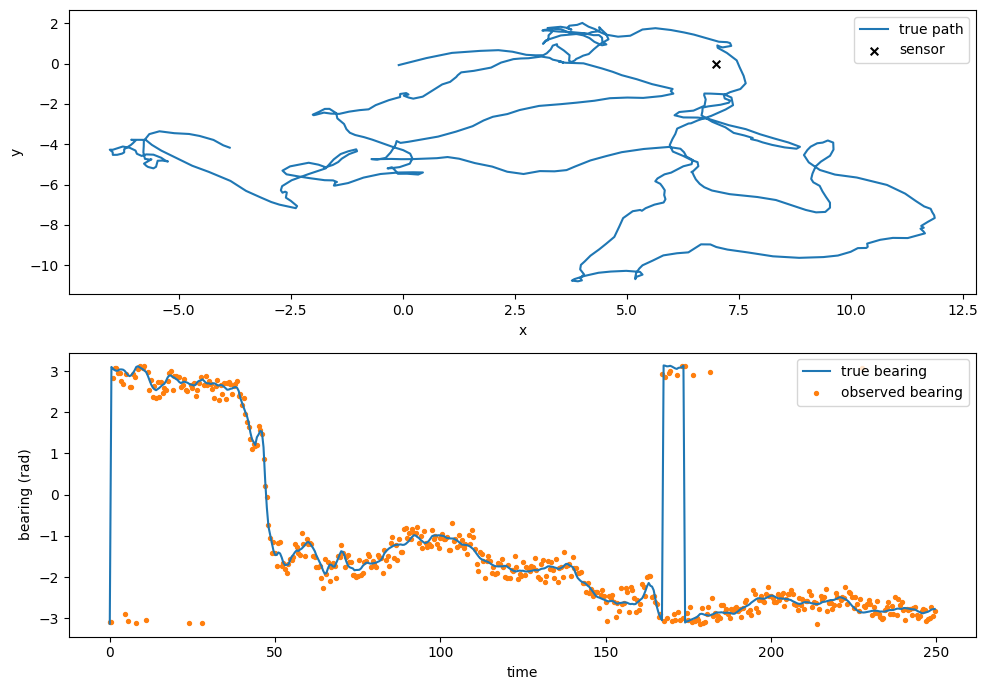

In [12]:
# Plot true trajectory and bearing observations
fig, axs = plt.subplots(2, 1, figsize=(10, 7))

axs[0].plot(bearing_states[:, 0], bearing_states[:, 1], label="true path")
axs[0].scatter(*sensor_xy, color="k", marker="x", label="sensor", s=30)
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].legend(loc="upper right")

axs[1].plot(t_emissions.squeeze(), true_bearings, label="true bearing")
axs[1].scatter(t_emissions.squeeze(), bearing_emissions[:, 0], s=8, color="C1", label="observed bearing")
axs[1].set_xlabel("time")
axs[1].set_ylabel("bearing (rad)")
axs[1].legend(loc="upper right")

plt.tight_layout()

### Filtering: Seamless inference, using a Differentiable Particle Filter

In [13]:
bearing_filtered = bearing_cdnlssm.filter(
    params=bearing_params,
    emissions=bearing_emissions,
    t_emissions=t_emissions,
    key=jr.PRNGKey(321),
    N_particles=1_000,
    warn=False,
)

print("Tracking DPF marginal log-likelihood:", float(bearing_filtered.marginal_loglik))

Tracking DPF marginal log-likelihood: -1050.5513519077404


### Visualize data and filtering results

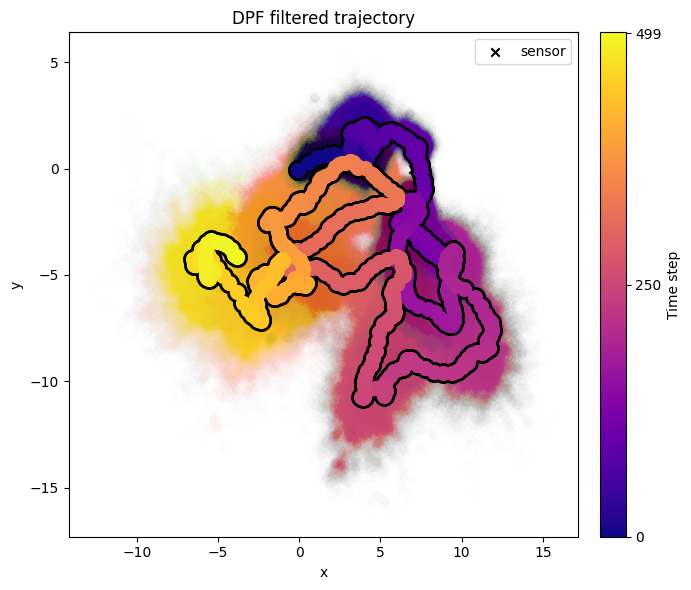

In [14]:
# Set-up for plotting the filtered trajectory
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
cmap = mpl.colormaps["plasma"]
points = []
colors = []

# Plot the true trajectory with a color gradient over time, and the particles at each time step colored by time as well
for t in range(T):
    ax.scatter(
        bearing_states[t, 0],
        bearing_states[t, 1],
        color="black",
        s=200,
        zorder=1
    )
    cval = t / T
    ax.scatter(
        bearing_states[t, 0],
        bearing_states[t, 1],
        color=cmap(cval),
        s=100,
        zorder=2,
    )

    # Keep track of each time and state for colorbar
    points.append([bearing_states[t, 0], bearing_states[t, 1]])
    colors.append(cval)

    ax.scatter(bearing_filtered.particles[t, :, 0], bearing_filtered.particles[t, :, 1], color=cmap(cval), alpha=0.005, zorder=1)

ax.scatter(*sensor_xy, color="k", marker="x", label="sensor")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="best")
ax.set_title("DPF filtered trajectory")

# Add colorbar for time
norm = mpl.colors.Normalize(vmin=0, vmax=T)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=0, vmax=T))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label='Time step')
cbar.set_ticks([0, T//2, T-1])
cbar.set_ticklabels([0, T//2, T-1])

plt.tight_layout()

## Comparison with EnKF: Same data, but Assuming Gaussian Emissions


### CD-NLGSSM Model definition: assuming Gaussian emissions

In [15]:
# CD-NLGSSM main model class import
from cd_dynamax import ContDiscreteNonlinearGaussianSSM

# Define de CD-NLSSM
bearing_cdnlgssm = ContDiscreteNonlinearGaussianSSM(
        state_dim=state_dim,
        emission_dim=emission_dim
)

**The Bearing Emission Model**

Gaussian emissions assumed, centered at bearing mean direction $\mu_k$ and power mean $m_k$, with diagonal covariance matrix $\Sigma_y = \mathrm{diag}(\sigma_y^2, \sigma_z^2)$.

In [16]:
# Define the emission function for the bearing tracking model
# This will be the mean of the Gaussian emissions
class LearnableBearingPowerFunction(NamedTuple):
    r"""Learnable Bearing power function

    Args:
        sensor_xy: 2D location of the sensor
        P0: power at reference distance r0
        n: path loss exponent for the power observation
        r0: reference distance for the power observation
    """

    # Learnable parameters
    sensor_xy: Union[Float[Array, "2"], ParameterProperties]
    P0: Union[Float[Array, "1"], ParameterProperties]
    n: Union[Float[Array, "1"], ParameterProperties]
    r0: Union[Float[Array, "1"], ParameterProperties]

    # Function to compute the drift
    def f(self, x, u=None, t=None):
        px, py, vx, vy = x
        r = jnp.sqrt((px - self.sensor_xy[0]) ** 2 + (py - self.sensor_xy[1]) ** 2)
        r = jnp.maximum(r, 1e-12)  # avoid log(0)
        bearing = jnp.arctan2(py - self.sensor_xy[1], px - self.sensor_xy[0])
        power = self.P0 - 10.0 * self.n * jnp.log10(r / self.r0)
        
        return jnp.array([bearing, power])

    def get_params(self):
        return _get_params(self)
    

# Define the emission covariance
sigma_y = 0.15  # Gaussian bearing noise std (radians)
sigma_z = 2.0  # Gaussian power noise std (dB)  (same meaning as before)

emission_cov=jnp.diag(
    jnp.array([sigma_y**2, sigma_z**2])
)

In [17]:
# Initialize the CD-NLGSSM with the same initial distribution, dynamics, and assumed Gaussian emissions
bearing_cdnlgssm_params, _ = bearing_cdnlgssm.initialize(
    initial_mean={
        "params": LearnableVector(params=initial_mean),
        "props": LearnableMatrix(params=ParameterProperties(trainable=False))
    },
    initial_cov={
        "params": LearnableMatrix(params=initial_cov),
        "props": LearnableMatrix(params=ParameterProperties(trainable=False))
    },
    dynamics_drift={
        "params": Learnable_BearingDrift(alpha=alpha),
        "props": None,  # Let us use the default parameter properties
    },
    dynamics_diffusion_coefficient={
        "params": LearnableMatrix(params=diffusion_coeff),
        "props": LearnableMatrix(params=ParameterProperties(trainable=False))
    },
    dynamics_diffusion_cov={
        "params": LearnableMatrix(params=diffusion_cov),
        "props": LearnableMatrix(params=ParameterProperties(trainable=False))
    },
    emission_function={
        "params": LearnableBearingPowerFunction(
            sensor_xy=sensor_xy,
            P0=P0,
            n=n,
            r0=r0,
        ),
        "props": None,  # Let us use the default parameter properties
    },
    emission_cov={
        "params": LearnableMatrix(params=emission_cov),
        "props": LearnableMatrix(params=ParameterProperties(trainable=False))
    },
)

### Filtering: inference, now using an Ensemble Kalman Filter

In [ ]:
bearing_cdnlgssm_filtered = bearing_cdnlgssm.filter(
    params=bearing_cdnlgssm_params,
    emissions=bearing_emissions,
    t_emissions=t_emissions,
    inputs=None,
    filter_type="EnKF",
    enkf_N_particles=1_000,
    warn=False,
)

print(
    "Gaussian (bearing+power) EnKF marginal log-likelihood:",
    float(bearing_cdnlgssm_filtered.marginal_loglik),
)

In [ ]:
# EnKF filtered positions
pos_mean_g = bearing_cdnlgssm_filtered.filtered_means[:, :2]
pos_cov_g = bearing_cdnlgssm_filtered.filtered_covariances[:, :2, :2]
pos_std_g = jnp.sqrt(jnp.diagonal(pos_cov_g, axis1=1, axis2=2))

# MSE for DPF and EnKF means (only on the position, not the velocity)
dpf_mse = jnp.mean((bearing_filtered.filtered_means[:, :2] - bearing_states[:, :2]) ** 2)
enkf_mse = jnp.mean((bearing_cdnlgssm_filtered.filtered_means[:, :2] - bearing_states[:, :2]) ** 2)

# Plot the true trajectory, the EnKF mean trajectory, and the DPF mean trajectory
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.plot(bearing_states[:, 0], bearing_states[:, 1], color="C0", label="true path")
ax.plot(pos_mean_g[:, 0], pos_mean_g[:, 1], color="C4", label="EnKF mean (Gaussian obs; MSE = {:.3f})".format(enkf_mse))
ax.plot(bearing_filtered.filtered_means[:, 0], bearing_filtered.filtered_means[:, 1], color="C3", label="DPF mean (non-Gaussian obs; MSE = {:.3f})".format(dpf_mse))
ax.scatter(*sensor_xy, color="k", marker="x", label="sensor")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="best")
ax.set_title("Mean Filtered Tracking Trajectories")
plt.tight_layout()